# Group Members:

<font color='blue'>**PUT NAMES OF YOUR TEAM MEMBERS HERE**

*   Ivan Luque
*   Martí Pascual
*   Joan Company

# Guide

In this practice we will implement stochastic gradient descent for some simple 0-1 classification tasks, focusing on logistic regression.

**Pre-requisites:** Before the practice, you should review the following topics:

*   Stochastic gradient descent
*   Logistic regression


\\

For any doubts before and after the practice, you can contact your teacher:

Gergely Neu - gergely.neu@upf.edu

Pablo Arias - pablo.arias@upf.edu

Adriano Pastore - adriano.pastore@upf.edu



\\

**Submission instructions**

1. Complete the code and answer the questions below.
1. Export the notebook with the answers using the menu option File->Download .ipynb.
1. Rename exported notebook with the format **lastnameUid.ipynb** where lastname is the first surname of **Member 1** in the form and Uid is their UPF ID.
1. Submit your solution via Aula Global by the deadline. **Only one member needs to complete this step**.

\\

**Grading**:

  The evaluation is based on results, conclusions and the commented code together.

[comment]: <> (Macros:)
$\newcommand{\m}{-}
\newcommand{\siprod}[2]{\langle#1,#2\rangle}
\newcommand{\iprod}[2]{\left\langle#1,#2\right\rangle}
\newcommand{\Siprod}[2]{\left\langle#1,#2\right\rangle_{|S}}
\newcommand{\biprod}[2]{\bigl\langle#1,#2\bigr\rangle}
\newcommand{\Biprod}[2]{\Bigl\langle#1,#2\Bigr\rangle}
\newcommand{\norm}[1]{\left\|#1\right\|}
\newcommand{\bnorm}[1]{\bigl\|#1\bigr\|}
\newcommand{\onenorm}[1]{\norm{#1}_1}
\newcommand{\twonorm}[1]{\norm{#1}_2}
\newcommand{\infnorm}[1]{\norm{#1}_\infty}
\newcommand{\tvnorm}[1]{\norm{#1}_{\mathrm{TV}}}
\newcommand{\Hnorm}[1]{\norm{#1}_{\mathcal{H}}}
\newcommand{\ev}[1]{\left\{#1\right\}}
\newcommand{\abs}[1]{\left|#1\right|}
\newcommand{\babs}[1]{\bigl|#1\bigr|}
\newcommand{\pa}[1]{\left(#1\right)}
\newcommand{\bpa}[1]{\bigl(#1\bigr)}
\newcommand{\Bpa}[1]{\Bigl(#1\Bigr)}
\newcommand{\BPA}[1]{\Biggl(#1\Biggr)}
\newcommand{\sign}{\mbox{sign}}
\newcommand{\real}{\mathbb{R}}
\newcommand{\ma}[1]{\boldsymbol{#1}}
\newcommand{\tras}[1]{#1^{\mathrm{T}}}
\newcommand{\herm}[1]{#1^{\mathrm{H}}}
\newcommand{\con}[1]{#1^{\mathrm{*}}}
\newcommand{\E}{\mathbb{E}}
\newcommand{\tech}[1]{\overline{#1}}
\newcommand{\nspace}{\!\!\!\!}
\newcommand{\nmbr}[1]{\oldstylenums{#1}}
\newcommand{\eg}{\emph{e.g}. } \newcommand{\Eg}{\emph{E.g}. }
\newcommand{\ie}{\emph{i.e}. } \newcommand{\Ie}{\emph{I.e}. }
\newcommand{\cf}{\emph{c.f}. } \newcommand{\Cf}{\emph{C.f}. }
\newcommand{\etc}{\emph{etc}. } \newcommand{\vs}{\emph{vs}. }
\newcommand{\wrt}{w.r.t\onedot } \newcommand{\dof}{d.o.f. }
\newcommand{\etal}{\emph{et al}. }
\newcommand{\R}{\mathbb{R}}
\newcommand{\sign}{\mathrm{sign}}
\newcommand{\eps}{\varepsilon}
\newcommand{\To}{\longrightarrow}
\DeclareMathOperator*{\argmin}{arg\,min}
\DeclareMathOperator*{\argmax}{arg\,max}$

**Instructions for answering the questions.**

Questions are indicated in blue. Some questions require answers in the form of text, some others require completing code. See the examples below. *Please do not modify the notebook outside of these cells.*

<font color='blue'>**(QUESTION 42)** Based on what you know at this moment, answer these questions:
1. What are your favorite subjects?
2. What are your favourite hobbies?
</font>

<font color='red'>**ANSWER**</font>

1. I only like one subject: "Optimization Techniques."
1. I like writing equations $e^{i\pi} + 1 = 0$

<font color='blue'>**(QUESTION 43)** This is a coding question. There is no <font color='red'>**ANSWER**</font> cell. Instead, you should complete the code cell following the question. Typically, you'll find TODOs in the code indicating the places that you are expected to complete.
</font>

In [1]:
a = None     # TODO substitute the None by a nice number to print
print("The number a is {}".format(a))

The number a is None


In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt


# Binary classification with logistic regression

Let $(x_i,y_i)_{i=1}^n$ be a data set of input-output pairs with each $x_i\in\real^d$ and $y_i\in\ev{-1,1}$. We will study the performance of linear classifiers parametrized by a vector $\theta\in\real^d$, assigning a binary label to each data point according to the rule
$$
	f_\theta(x) = \sign(\iprod{\theta}{x}) \in \ev{-1,1}.
$$
Ideally, we would like to minimize the binary classification loss (often called 0-1 loss) defined for a data point $x,y$  and a parameter $\theta$ as
$$
\ell^{0-1}(\theta;x,y) = \mathbb{I}_{\sign(\iprod{\theta}{x}) \neq y} = \begin{cases}
1 & \mbox{if $y \neq \sign(\iprod{\theta}{x})$}
\\
0 & \mbox{otherwise}.
\end{cases}
$$
The loss can be conveniently rewritten in terms of the so-called *margin* $\iprod{\theta}{x} \cdot y$, whose value can be seen as the ``confidence'' in the correct prediction $\sign(\iprod{\theta}{x})$. Indeed, notice that the sign of the margin is positive whenever the predicted label is correct, and is negative otherwise, and thus the 0-1 loss can be simply written as
$$
\ell^{0-1}(\theta;x,y) = \pa{1-\sign(\iprod{\theta}{x} \cdot y)} / 2
$$
This loss function is, unfortunately, not convex or differentiable in $\theta$ so it cannot be optimized using gradient-based techniques. To this end, it is common to replace the 0-1 loss with convex differentiable alternatives such as the hinge loss defined as
$$
\ell^{\text{hinge}}(\theta;x,y) = \max\ev{0,1-\iprod{\theta}{x} \cdot y},
$$
or the logistic loss defined as
$$
\ell(\theta;x,y) = \log_2\pa{1+e^{-\iprod{\theta}{x} \cdot y}}.
$$
These two loss functions are both convex and can be shown to upper-bound the 0-1 loss (after appropriate scaling), which suggests that minimizing them will also lead to good predictions. (For simplicity, usual implementations of the log loss use the natural logarithm instead of $\log_2$; this is the convention we will follow in this lab as well.) Additionally, the logistic loss is smooth and differentiable with continuous gradients with respect to $\theta$. This loss function will be the main character of this lab, and thus we omit its upper index for clarity.

In the lab, we will focus on minimizing the empirical risk for binary classification. For the definitions, we will use the shorthand notation $\ell_i(\theta) = \ell(\theta;x_i,y_i)$ for each loss function, and will write the empirical risks as:
$$
\widehat{L}_n^{0-1}(\theta) = \frac 1n \sum_{i=1}^n \ell^{0-1}_i(\theta),
$$
$$
\widehat{L}_n^{\text{hinge}}(\theta) = \frac 1n \sum_{i=1}^n \ell^{\text{hinge}}_i(\theta)
$$
$$
\widehat{L}_n(\theta) = \frac 1n \sum_{i=1}^n \ell_i(\theta)
$$
Minimizing the last of these loss functions is commonly known as *logistic regression*, the topic of this lab.

We will specifically study the performance of *stochastic gradient descent* (SGD), which is the most common workhorse method for optimization in machine learning. In this context (commonly called ``finite-sum minimization'' in optimization), SGD consists of computing unbiased estimators of the gradient of $\widehat{L}_n$ by sampling a *minibatch* of indices and taking the average of the gradients at the selected data points as a surrogate for the gradient. Precisely, SGD is an iterative scheme that starts out with an initial parameter vector $\theta_1 \in \real^d$ and then proceeds for a sequence of iterations $t=1,2,\dots,T$ with the following computations:
- sample minibatch $B_t \subset \ev{1,2,\dots,n}$ with $|B_t| = b$,
- compute gradient estimate
$$
\widehat{g}_t = \frac{1}{b} \sum_{i\in B_t} \nabla_\theta \ell_i(\theta),
$$
- update parameters as
$$
\theta_{t+1} = \theta_t - \eta g_t,
$$
where $\eta > 0$ is a positive stepsize or learning-rate parameter.

More advanced methods make use of adaptive stepsizes that depend on the sequence of data points and gradients encountered during optimization; today we will focus on fixed stepsizes. The number of iterations $T$ is often parametrized as $T = E \cdot b \cdot n$, with $E$ called the number of *epochs* or *passes* over the data set.

In the first half, your task is to produce some basic plots and compute some derivatives to get familiar with the problem of binary classification and the loss functions we will use.

# <font color='red'> **IMPORTANT DISCLAIMER:** </font>
<font color='red'> In this lab, our focus is on matters of **optimization** only, and thus we are not following proper machine-learning methodology during evaluation and testing. In particular, we will only study the convergence of the **training loss** without worrying about the test loss. A proper ML methodology would involve a validation set for tuning hyperparameters and a test set for reporting results. To this end, some of the tasks you'll need to perform are non-standard in ML (e.g., plotting the test loss in the MNIST experiments). These operations are often both too expensive and too risky in a practical ML setup due to the increased computational load and the potential of overfitting. You should think of this exercise as a way to get a better understanding of the dynamics of SGD for optimization in isolation, without having to think about the issues specifically related to machine learning. </font>

<font color='blue'>**(QUESTION 1.1)** For a fixed one-dimensional data point $x = 1$ and $y=1$, plot the functions $\ell^{0-1}$, $\ell^{\text{hinge}}$ and the logistic loss $\ell$. What is the relation between these functions?
</font>

<font color='red'>**ANSWER**</font>



Similarities:
  - All three curves penalise negative θ heavily and become negligible when θ is strongly positive. Each is built to guide the same binary task.
  - Hinge and Logistic and convex.

Dissimilarities:
  - 0-1 jumps like a switch, hinge descends in a straight ramp that flattens at θ = 1, while logistic goes smoothly and never quite hits zero. That makes 0-1 non-optimisable, hinge convex but non-smooth, and logistic both convex and smooth.

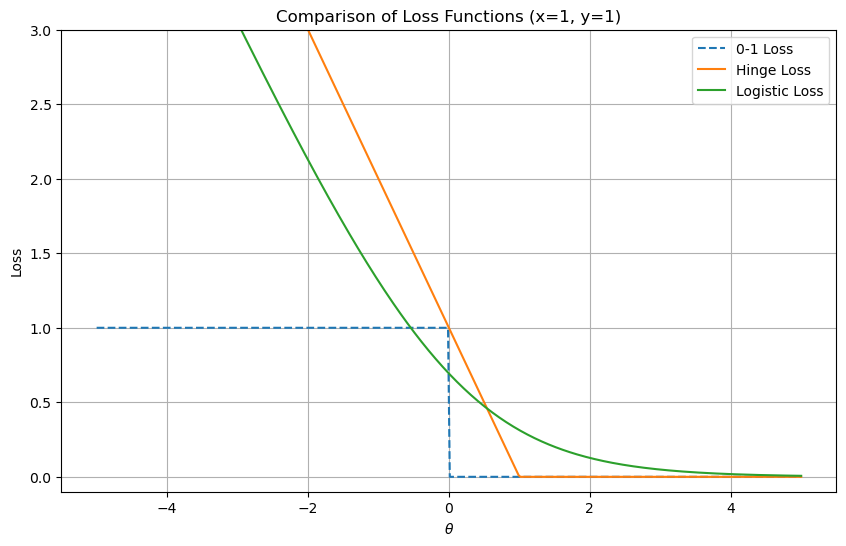

In [3]:
# Define the three loss functions for x=1, y=1
def zero_one_loss(theta):
    return (1 - np.sign(theta)) / 2

def hinge_loss(theta):
    return max(0, 1 - theta * 1)

def logistic_loss(theta):
    return np.log(1 + np.exp(-theta * 1))

# Generate theta values
theta_values = np.linspace(-5, 5, 400)

# Calculate loss values
zero_one_losses = [zero_one_loss(theta) for theta in theta_values]
hinge_losses = [hinge_loss(theta) for theta in theta_values]
logistic_losses = [logistic_loss(theta) for theta in theta_values]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(theta_values, zero_one_losses, label='0-1 Loss', linestyle='--')
plt.plot(theta_values, hinge_losses, label='Hinge Loss')
plt.plot(theta_values, logistic_losses, label='Logistic Loss')

plt.xlabel(r'$\theta$')
plt.ylabel('Loss')
plt.title('Comparison of Loss Functions (x=1, y=1)')
plt.legend()
plt.grid(True)
plt.ylim([-0.1, 3]) # Adjust y-axis limit for better visualization
plt.show()

<font color='blue'>**(QUESTION 1.2)** Calculate the gradients of the three loss functions for a generic data point $x\in\real^d$, $y\in\ev{-1,1}$.
</font>

<font color='red'>**ANSWER**</font>



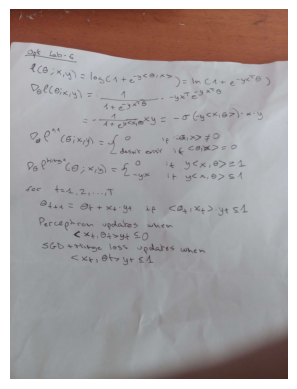

In [5]:
from matplotlib import image as mpimg
from matplotlib import pyplot as plt

img = mpimg.imread("Q1.2.jpg")  # supports .png, .jpg, etc.
plt.imshow(img)
plt.axis('off')
plt.show()

### Two-dimensional toy example

In this part, we will generate a simple two-dimensional toy data set and study the convergence of SGD with the logistic loss.

In [6]:
## Gaussian Data Generation Function

def generate_gaussian_data(mean1, cov1, mean2, cov2, n_samples):
    """
    Generates synthetic data from two Gaussian distributions for binary classification.

    Args:
        mean1 (np.ndarray): Mean vector for the first Gaussian distribution.
        cov1 (np.ndarray): Covariance matrix for the first Gaussian distribution.
        mean2 (np.ndarray): Mean vector for the second Gaussian distribution.
        cov2 (np.ndarray): Covariance matrix for the second Gaussian distribution.
        n_samples (int): The total number of samples to generate (split equally between classes).

    Returns:
        tuple: A tuple containing:
            - X (np.ndarray): The generated data points (n_samples, n_features).
            - y (np.ndarray): The labels for the data points (+1 or -1).
    """
    # Ensure the number of samples is even
    if n_samples % 2 != 0:
        print("Warning: n_samples should be even. Adjusting n_samples to be even.")
        n_samples += 1

    n_samples_per_class = n_samples // 2

    # Generate data for the first class (label +1)
    X1 = np.random.multivariate_normal(mean1, cov1, n_samples_per_class)
    y1 = np.ones(n_samples_per_class)

    # Generate data for the second class (label -1)
    X2 = np.random.multivariate_normal(mean2, cov2, n_samples_per_class)
    y2 = -np.ones(n_samples_per_class)

    # Combine the data and labels
    X = np.vstack((X1, X2))
    y = np.concatenate((y1, y2))

    # Shuffle the data to mix the classes
    shuffle_idx = np.random.permutation(n_samples)
    X = X[shuffle_idx]
    y = y[shuffle_idx]

    return X, y

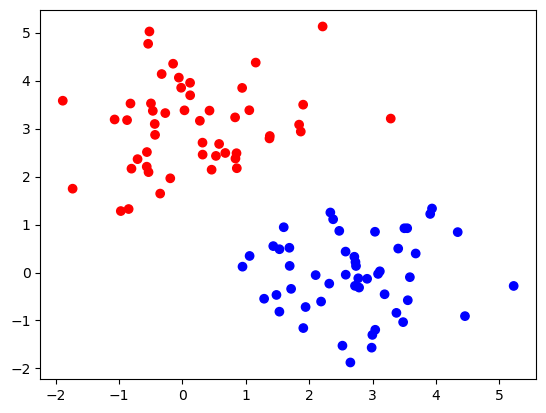

In [7]:
# generate a separable data set using the above function

seed = 123456789
np.random.seed(seed)

mean1 = [0,3]
cov1 = [[1,0],[0,1]]
mean2 = [3,0]
cov2 = [[1,0],[0,1]]
X, y = generate_gaussian_data(mean1, cov1, mean2, cov2, 100)
plt.scatter(X[:,0], X[:,1], c = y, cmap = "bwr")


<font color='blue'>**(QUESTION 2.1)** Use the gradients calculated above and fill out the missing details in the code below to implement SGD.
</font>

<font color='red'>**ANSWER**</font>



In [8]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import SGDClassifier

# Function to implement stochastic gradient descent for logistic regression
def sgd_logistic_regression(X, y, learning_rate, epochs, batch_size):
    """
    Implements stochastic gradient descent for logistic regression and tracks parameters.

    Args:
        X (np.ndarray): The training data points (n_samples, n_features).
        y (np.ndarray): The labels for the training data points (+1 or -1).
        learning_rate (float): The step size for the gradient updates.
        epochs (int): The number of passes over the entire dataset.
        batch_size (int): The number of samples in each minibatch.

    Returns:
        tuple: A tuple containing:
            - theta (np.ndarray): The learned parameter vector.
            - parameter_history (list): A list of parameter vectors at each update step.
    """
    n_samples, n_features = X.shape

    # Initialize parameters (theta) with zeros
    theta = np.zeros(n_features)

    # List to store the parameter vectors at each step
    parameter_history = [theta.copy()]

    for epoch in range(epochs):
        # Shuffle the data for each epoch
        shuffle_idx = np.random.permutation(n_samples)
        X_shuffled = X[shuffle_idx]
        y_shuffled = y[shuffle_idx]

        for i in range(0, n_samples, batch_size):
            # Get minibatch
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # TODO: Calculate the gradient for the logistic loss
            margins = y_batch * (X_batch @ theta)
            probs = 1.0 / (1.0 + np.exp(margins))
            gradient = -np.mean((y_batch[:, np.newaxis] * X_batch) * probs[:, np.newaxis], axis=0)

            # TODO: Update parameters
            theta = theta - learning_rate * gradient

            # Store the updated parameters
            parameter_history.append(theta.copy())

    return theta, parameter_history

# Plot the learned separator
def plot_separator(X, y, theta):
    """
    Plots the data points and the linear separator defined by theta.

    Args:
        X (np.ndarray): The data points (n_samples, n_features).
        y (np.ndarray): The labels for the data points (+1 or -1).
        theta (np.ndarray): The parameter vector defining the separator.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr")

    # Plot the decision boundary defined by theta[0]*x1 + theta[1]*x2 = 0
    # Solving for x2: x2 = - (theta[0] / theta[1]) * x1
    x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    # Avoid division by zero if theta[1] is very small
    if np.abs(theta[1]) > 1e-6:
        x2_vals = - (theta[0] / theta[1]) * x1_vals
        plt.plot(x1_vals, x2_vals, color='green', linestyle='--', linewidth=2, label='Learned Separator')
    elif np.abs(theta[0]) > 1e-6: # Vertical line if theta[1] is zero
        plt.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Learned Separator')
    else:
        # If both are zero, the separator is not well-defined
        print("Warning: theta is close to zero. Cannot plot a meaningful separator.")


    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Data with Learned Separator (Logistic Regression via SGD)")
    plt.legend()
    plt.grid(True)
    plt.show()

<font color='white'>**(QUESTION 2.2)** Use the code above to perform SGD on the toy data set generated previously, and plot the learned separator using the plot_separator utility provided below. Plot the separator corresponding to the parameter vectors after $1$, $10$ and $100$ SGD updates. What do you observe?
</font>

<font color='red'>**ANSWER**</font>



Learned parameter vector (theta): [-2.3847928   2.71048673]
Number of parameter updates: 10001
Plot after 1 SGD update:


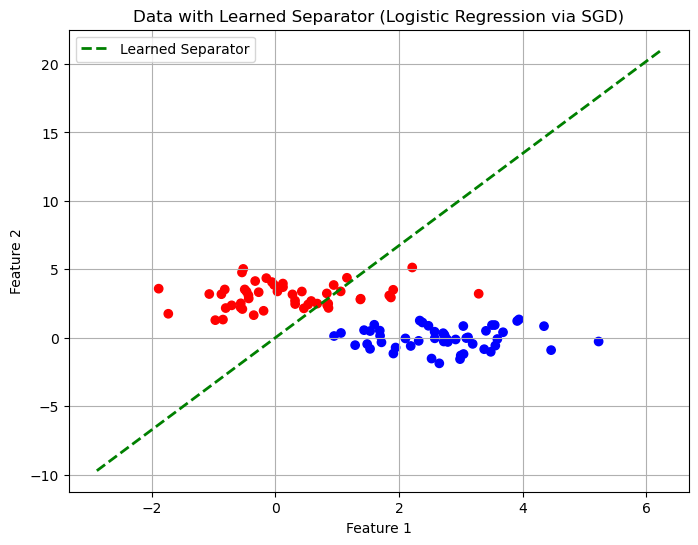

Plot after 10 SGD updates:


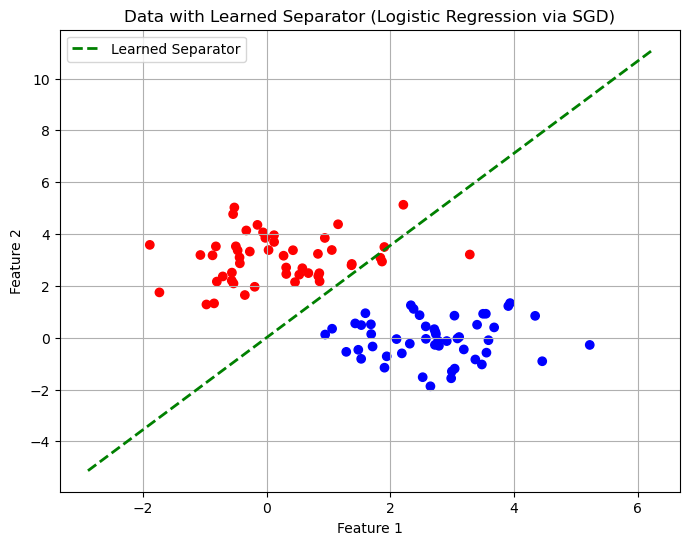

Plot after 100 SGD updates:


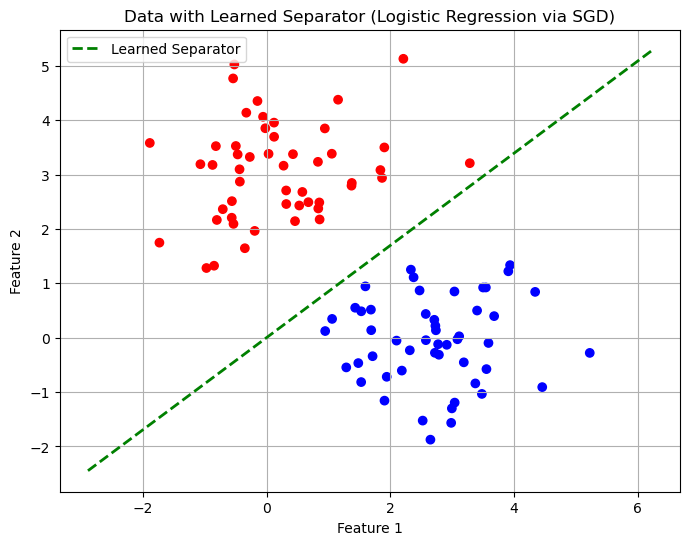

In [9]:
# hyperparameters
learning_rate = 0.01
epochs = 100
batch_size = 1

seed = 987654321
np.random.seed(seed)

theta_learned, param_hist = sgd_logistic_regression(X, y, learning_rate, epochs, batch_size)

print("Learned parameter vector (theta):", theta_learned)
print("Number of parameter updates:", len(param_hist))

print("Plot after 1 SGD update:")
plot_separator(X, y, param_hist[1])


if len(param_hist) > 10:
    print("Plot after 10 SGD updates:")
    plot_separator(X, y, param_hist[10])
else:
    print("Less than 10 updates available.")


if len(param_hist) > 100:
    print("Plot after 100 SGD updates:")
    plot_separator(X, y, param_hist[100])
else:
    print("Less than 100 updates available.")

We trained a logistic regression model using stochastic gradient descent (SGD) on a 2D toy dataset and plotted the learned decision boundary after 1, 10, and 100 updates.

After 1 update, the separator is poorly aligned. It reflects the influence of only the first data point seen and doesn't generalize.

After 10 updates, the decision boundary starts to shift closer to the true class boundary, although it still misclassifies a noticeable number of points. The learning process has just begun adapting.

After 100 updates, the separator is much better aligned with the data distribution, indicating successful convergence. Most points are correctly separated, showing that SGD progressively refines the model with each update.

Observation: As expected, with more SGD updates, the decision boundary improves. This demonstrates how logistic regression using SGD converges gradually with each parameter update, even with noisy single-sample steps (batch size = 1).

<font color='blue'>**(QUESTION 2.3)** Complete the code below to evaluate the logistic loss of a parameter vector theta on a data set of inputs X and outputs y. Plot the level lines of the logistic loss and the sequence of iterates computed by SGD.
</font>

<font color='red'>**ANSWER**</font>



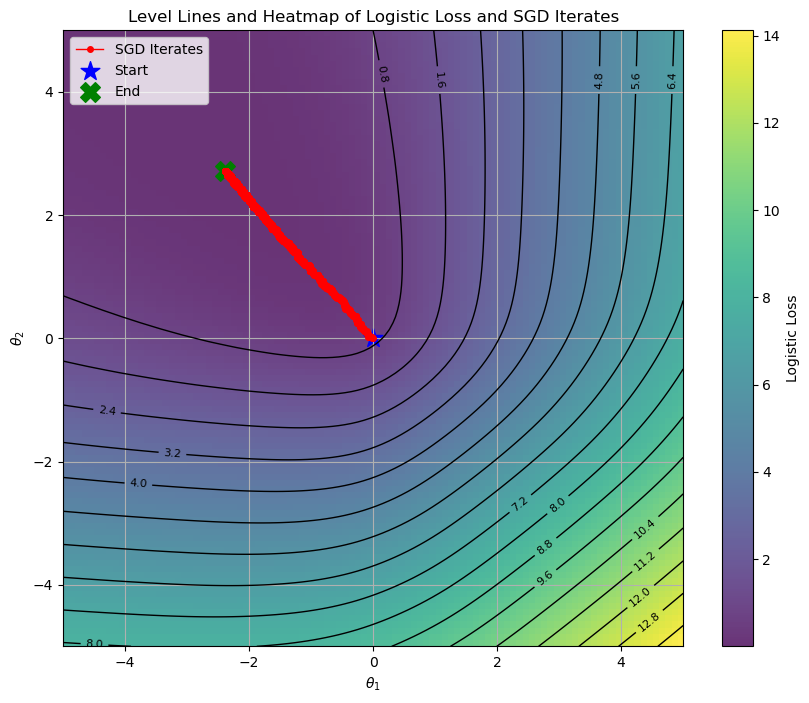

In [10]:
# Function to calculate logistic loss on the full batch of data
def calculate_logistic_loss(X, y, theta):
    """
    Calculates the average logistic loss for a given parameter vector and data.

    Args:
        X (np.ndarray): The data points (n_samples, n_features).
        y (np.ndarray): The labels (+1 or -1).
        theta (np.ndarray): The parameter vector.

    Returns:
        float: The average logistic loss.
    """
    # TODO: compute the logistic loss on the batch of data given as input
    margins = y * (X.dot(theta))
    losses = np.log1p(np.exp(-margins))
    loss = np.mean(losses)
    return loss

# Function to calculate 0-1 loss
def calculate_zero_one_loss(X, y, theta):
    """
    Calculates the average logistic loss for a given parameter vector and data.

    Args:
        X (np.ndarray): The data points (n_samples, n_features).
        y (np.ndarray): The labels (+1 or -1).
        theta (np.ndarray): The parameter vector.

    Returns:
        float: The average logistic loss.
    """
    predictions = np.sign(np.dot(X, theta))
    # Handle cases where prediction is exactly 0 (should not happen with floating points typically)
    # If dot product is 0, sign is 0. Assume we predict +1 or -1 arbitrarily, e.g., +1.
    predictions[predictions == 0] = 1
    loss = np.mean(predictions != y)
    return loss

# Create a grid of theta values to evaluate the loss function
theta1_min, theta1_max = -5, 5
theta2_min, theta2_max = -5, 5
theta1_grid = np.linspace(theta1_min, theta1_max, 100)
theta2_grid = np.linspace(theta2_min, theta2_max, 100)
Theta1, Theta2 = np.meshgrid(theta1_grid, theta2_grid)

# Calculate the loss for each point in the grid
Loss_grid = np.zeros_like(Theta1)
for i in range(Theta1.shape[0]):
    for j in range(Theta1.shape[1]):
        theta_eval = np.array([Theta1[i, j], Theta2[i, j]])
        Loss_grid[i, j] = calculate_logistic_loss(X, y, theta_eval)

# Plot a heatmap and the level lines of the loss function
plt.figure(figsize=(10, 8))
plt.imshow(Loss_grid, extent=[theta1_min, theta1_max, theta2_min, theta2_max], origin='lower', cmap='viridis', aspect='auto', alpha=0.8)
plt.colorbar(label='Logistic Loss')
contour = plt.contour(Theta1, Theta2, Loss_grid, levels=20, colors='black', linewidths=1)
plt.clabel(contour, inline=1, fontsize=8)

# Plot the sequence of iterates
param_hist_array = np.array(param_hist)
plt.plot(param_hist_array[:, 0], param_hist_array[:, 1], marker='o', linestyle='-', color='red', markersize=4, linewidth=1, label='SGD Iterates')
plt.scatter(param_hist_array[0, 0], param_hist_array[0, 1], color='blue', marker='*', s=200, label='Start')
plt.scatter(param_hist_array[-1, 0], param_hist_array[-1, 1], color='green', marker='X', s=200, label='End')


plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('Level Lines and Heatmap of Logistic Loss and SGD Iterates')
plt.legend()
plt.grid(True)
plt.show()

<font color='blue'>**(QUESTION 2.4)** Complete the function below to plot the norm of the sequence of parameter vectors computed by SGD. Based on the two plots, what can you say about the convergence of the iterates?
</font>

We can say that the convergence increases exponentially until more or less 1000 iterations and then it starts and slow process, meaning the convergence is obtained in the long term. This is supported by the two plots. In the heatmap specifically we can clearly distinguish that at the beggining is converging faster that is why it is not a straight line and when it approaches convergence it assembles a straight line because there are many iterations involved.

<font color='red'>**ANSWER**</font>



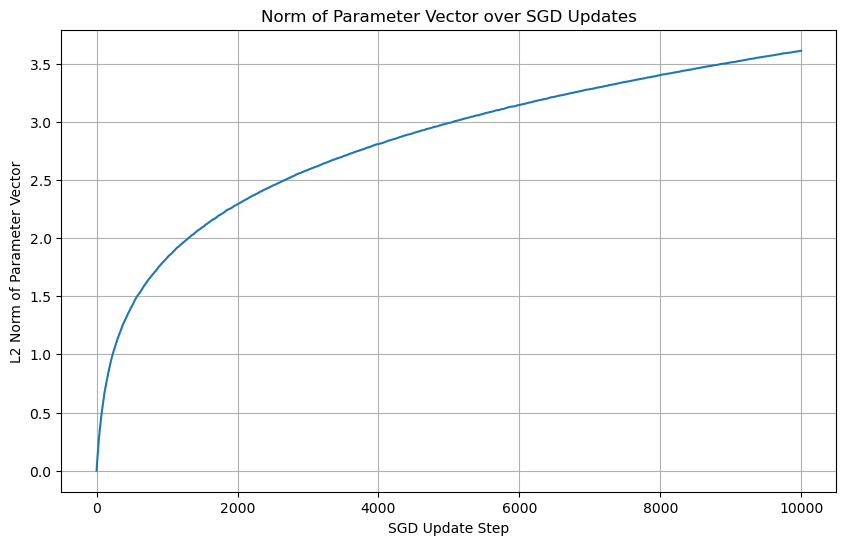

In [11]:
# Function to calculate the norm of parameter vectors over time
def plot_parameter_norm(parameter_history):
    """
    Calculates and plots the L2 norm of the parameter vector at each step.

    Args:
        parameter_history (list): A list of parameter vectors at each update step.
    """
    # TODO compute vector of parameter norms. (Each entry i should be the norm of parameter vector i from parameter_history.)
    norms = [np.linalg.norm(theta) for theta in parameter_history]

    plt.figure(figsize=(10, 6))
    plt.plot(norms)
    plt.xlabel("SGD Update Step")
    plt.ylabel("L2 Norm of Parameter Vector")
    plt.title("Norm of Parameter Vector over SGD Updates")
    plt.grid(True)
    plt.show()

plot_parameter_norm(param_hist)

<font color='blue'>**(QUESTION 2.5)** Plot the evolution of the logistic loss and the 0-1 loss for the sequence of parameters returned by SGD, with the batch size parameter changing between $b \in \ev{1, 8, 16}$ and the stepsize changing between $\eta \in \ev{0.001, 0.01, 0.1}$. Comment on the observed behavior for different step sizes and batch sizes. What happens when the step size is too large or too small? What are the advantages/disadvantages of using larger or smaller batches?
</font>

From the different plots it is clear that the binary loss drops to 0 almost immediately in every run, so after those first few updates it appears practically insensitive to either the stepsize or the batch size. For the logistic loss, performance does depend on the hyper-parameters: the largest stepsize that still keeps the curve stable drives the loss down fastest η = 0.1, independent of batch size. 
The advantages/disadvantages of using larger or smaller batches are the following: 
Larger: smoother gradients and fewer iterations per epoch, but higher update cost and a greater risk of getting stuck in shallow minima.
Smaller: cheaper, more frequent updates and enough gradient noise to help escape poor minima leading to less loss, but convergence is slower and the path is noisier.

<font color='red'>**ANSWER**</font>



Running SGD with learning_rate=0.001, batch_size=1
Running SGD with learning_rate=0.001, batch_size=8
Running SGD with learning_rate=0.001, batch_size=16
Running SGD with learning_rate=0.01, batch_size=1
Running SGD with learning_rate=0.01, batch_size=8
Running SGD with learning_rate=0.01, batch_size=16
Running SGD with learning_rate=0.1, batch_size=1
Running SGD with learning_rate=0.1, batch_size=8
Running SGD with learning_rate=0.1, batch_size=16


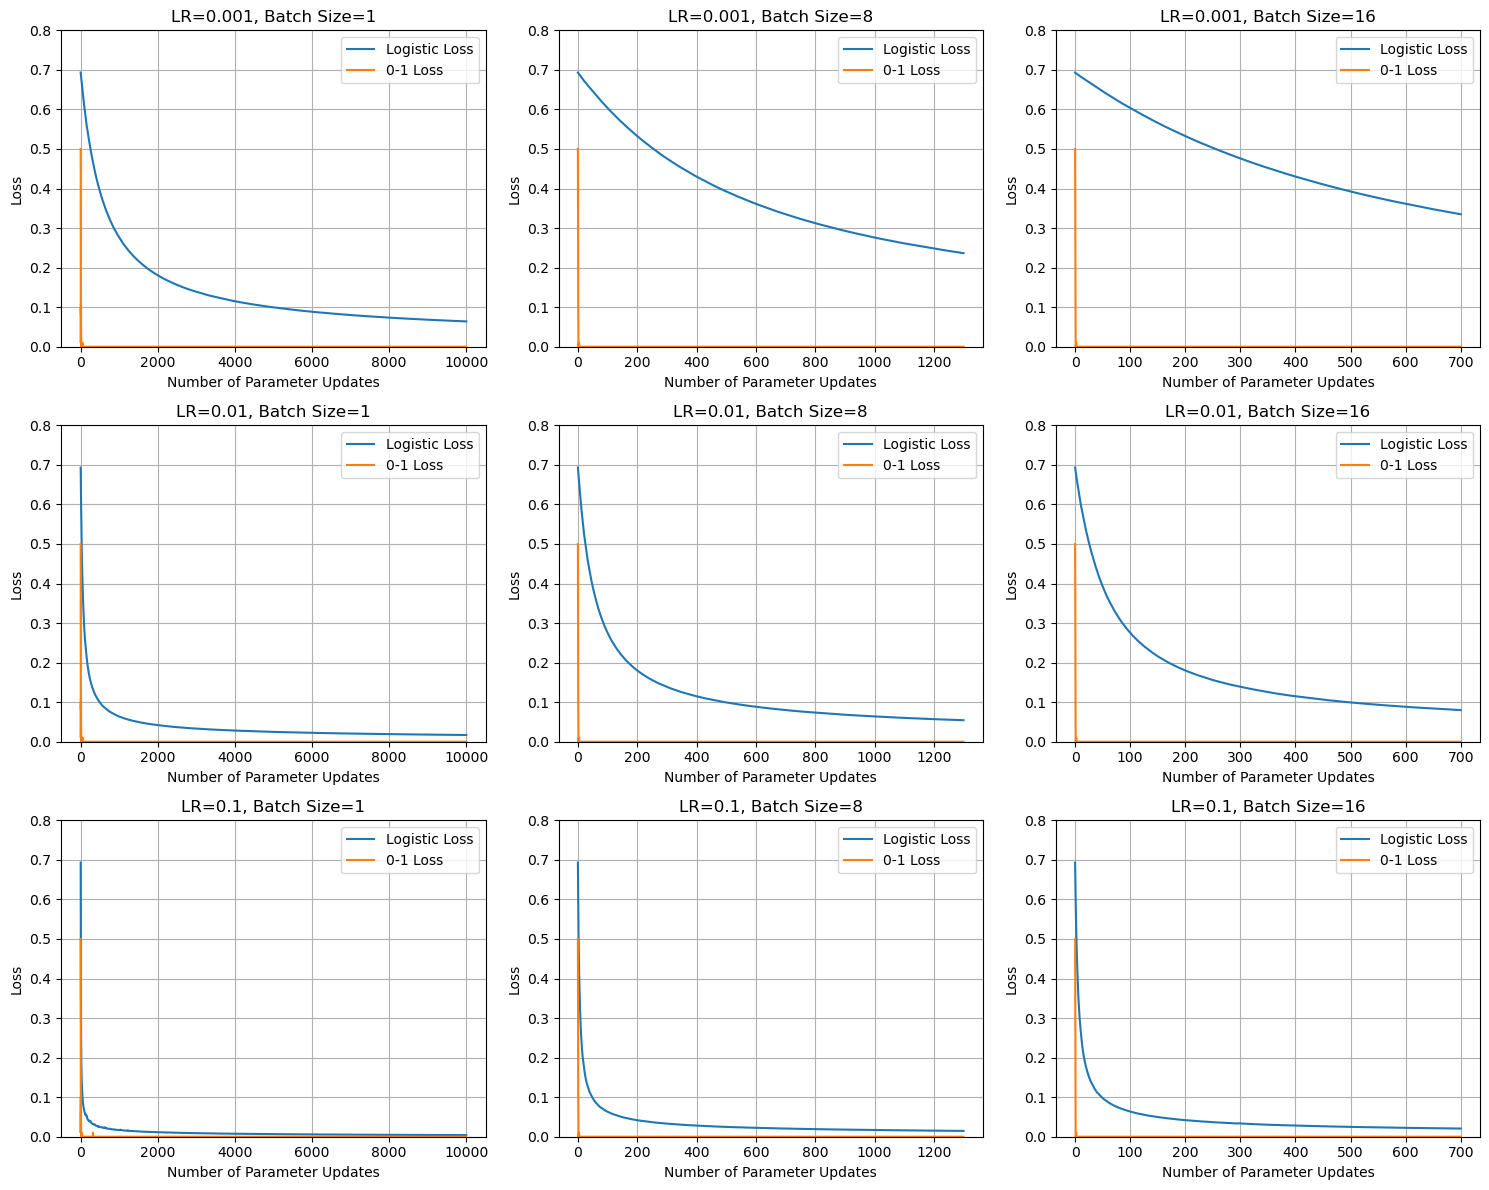

In [12]:
# Define hyperparameter grids
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [1, 8, 16]
epochs_for_plot = 100 # Run for more epochs to see convergence over many updates

fig, axes = plt.subplots(len(learning_rates), len(batch_sizes), figsize=(15, 12))

# Flatten axes for easier iteration
axes = axes.ravel()

plot_idx = 0

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Running SGD with learning_rate={lr}, batch_size={bs}")
        # Ensure reproducibility for each run
        np.random.seed(seed)

        theta_learned, parameter_history = sgd_logistic_regression(X, y, lr, epochs_for_plot, bs)

        # Calculate loss at each step using the full dataset
        logistic_losses = [calculate_logistic_loss(X, y, theta) for theta in parameter_history]
        zero_one_losses = [calculate_zero_one_loss(X, y, theta) for theta in parameter_history]

        # Plotting
        ax = axes[plot_idx]
        ax.plot(logistic_losses, label='Logistic Loss')
        ax.plot(zero_one_losses, label='0-1 Loss')

        ax.set_title(f'LR={lr}, Batch Size={bs}')
        ax.set_xlabel("Number of Parameter Updates")
        ax.set_ylabel("Loss")
        ax.set_ylim([0, 0.8])
        ax.legend()
        ax.grid(True)

        plot_idx += 1

plt.tight_layout()
plt.show()

 <font color='blue'>**(QUESTION 2.6)** Repeat the experiment of Question 2.2 with a more challenging data set as generated below, and discuss the results.
</font>

In the first dataset, the two classes form two distinct clusters, so logistic regression trained with SGD finds a perfect linear decision boundary. In the second, more challenging dataset, the red and blue classes overlap extensively, so no linear boundary can fully separate them; the SGD-learned separator necessarily makes many misclassifications.

<font color='red'>**ANSWER**</font>

C:\Users\joan\AppData\Local\Temp\ipykernel_22672\802598057.py:27: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X1 = np.random.multivariate_normal(mean1, cov1, n_samples_per_class)
C:\Users\joan\AppData\Local\Temp\ipykernel_22672\802598057.py:31: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X2 = np.random.multivariate_normal(mean2, cov2, n_samples_per_class)


Learned parameter vector (theta): [-0.69392101  0.84879986]
Number of parameter updates: 10001


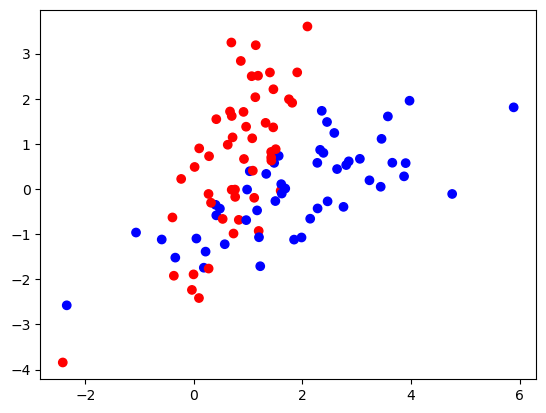

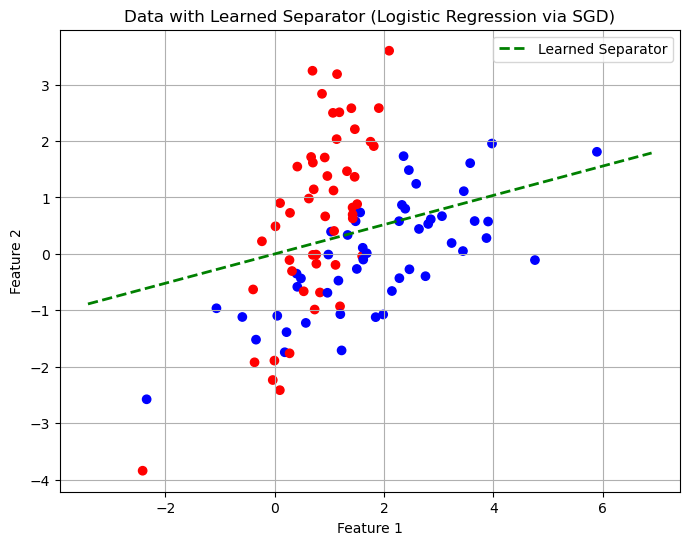

In [13]:
# generate a non-separable data set
seed = 666
np.random.seed(seed)

mean1 = [1,1]
cov1 = [[1,3],[0,1]]
mean2 = [2,0]
cov2 = [[1,0],[2,1]]
X, y = generate_gaussian_data(mean1, cov1, mean2, cov2, 100)
plt.scatter(X[:,0], X[:,1], c = y, cmap = "bwr")


# set hyperparameters for the experiment
learning_rate = 0.01
epochs = 100
batch_size = 1

seed = 987654321
np.random.seed(seed)

theta_learned, param_hist = sgd_logistic_regression(X, y, learning_rate, epochs, batch_size)

print("Learned parameter vector (theta):", theta_learned)
print("Number of parameter updates:", len(param_hist))

plot_separator(X, y, param_hist[10])

<font color='blue'>**(QUESTION 2.7)** Plot the level lines of the logistic loss and the sequence of iterates computed by SGD. On a separate plot, show the norm of the sequence of parameter vectors computed by SGD. How do the results compare with the previous plot generated for separable data?
</font>

<font color='red'>**ANSWER**</font>

Comparing the results with the previous plot we can distinguish that for non-separable data the loss surface is a single convex bowl, so the SGD trajectory bends directly into the unique minimum and then just jitters around it. 

The L2 norm now climbs to more or less 1.1 with small stochastic oscillations. Previously the norm rose past 3 and was still drifting up proving that for separable data logistic loss is driven down by letting the weights grow without bound, whereas for non-separable data it reaches a finite optimum.

In conclusion, separable data lets logistic loss approach zero only by growing the weight norm without bound, whereas non-separable data has a true interior minimiser, so the algorithm converges to a compact region instead of drifting away.


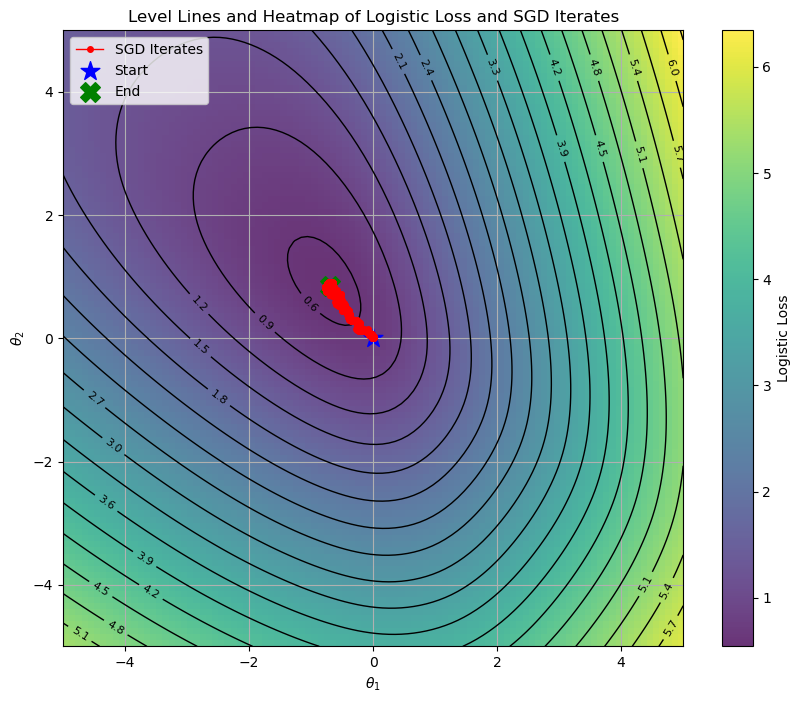

In [14]:
# Create a grid of theta values to evaluate the loss function
theta1_min, theta1_max = -5, 5
theta2_min, theta2_max = -5, 5
theta1_grid = np.linspace(theta1_min, theta1_max, 100)
theta2_grid = np.linspace(theta2_min, theta2_max, 100)
Theta1, Theta2 = np.meshgrid(theta1_grid, theta2_grid)

# Calculate the loss for each point in the grid
Loss_grid = np.zeros_like(Theta1)
for i in range(Theta1.shape[0]):
    for j in range(Theta1.shape[1]):
        theta_eval = np.array([Theta1[i, j], Theta2[i, j]])
        Loss_grid[i, j] = calculate_logistic_loss( X, y, theta_eval)

# Plot a heatmap and the level lines of the loss function
plt.figure(figsize=(10, 8))
plt.imshow(Loss_grid, extent=[theta1_min, theta1_max, theta2_min, theta2_max], origin='lower', cmap='viridis', aspect='auto', alpha=0.8)
plt.colorbar(label='Logistic Loss')
contour = plt.contour(Theta1, Theta2, Loss_grid, levels=20, colors='black', linewidths=1)
plt.clabel(contour, inline=1, fontsize=8)

# Plot the sequence of iterates
param_hist_array = np.array(param_hist)
plt.plot(param_hist_array[:, 0], param_hist_array[:, 1], marker='o', linestyle='-', color='red', markersize=4, linewidth=1, label='SGD Iterates')
plt.scatter(param_hist_array[0, 0], param_hist_array[0, 1], color='blue', marker='*', s=200, label='Start')
plt.scatter(param_hist_array[-1, 0], param_hist_array[-1, 1], color='green', marker='X', s=200, label='End')


plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('Level Lines and Heatmap of Logistic Loss and SGD Iterates')
plt.legend()
plt.grid(True)
plt.show()

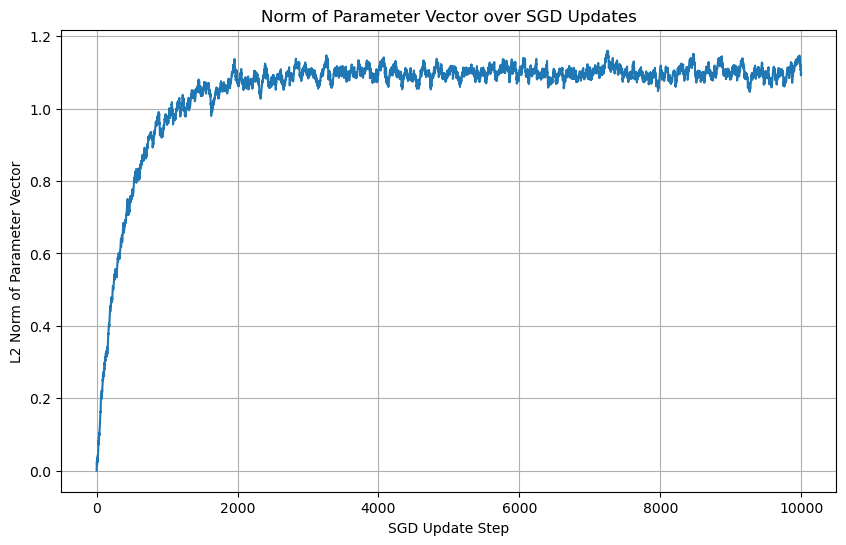

In [15]:
# Function to calculate the norm of parameter vectors over time
def plot_parameter_norm(parameter_history):
    """
    Calculates and plots the L2 norm of the parameter vector at each step.

    Args:
        parameter_history (list): A list of parameter vectors at each update step.
    """
    # TODO compute vector of parameter norms. (Each entry i should be the norm of parameter vector i from parameter_history.)
    norms = [np.linalg.norm(theta) for theta in parameter_history]

    plt.figure(figsize=(10, 6))
    plt.plot(norms)
    plt.xlabel("SGD Update Step")
    plt.ylabel("L2 Norm of Parameter Vector")
    plt.title("Norm of Parameter Vector over SGD Updates")
    plt.grid(True)
    plt.show()

plot_parameter_norm(param_hist)

 <font color='blue'>**(QUESTION 2.8)** Repeat the experiment of Question 2.3 with the non-separable data set, and discuss the results as in your answer to Question 2.4. Is there a clearer conclusion now? Which of the tested combinations of learning rate / batch size would you recommend most?
</font>

<font color='red'>**ANSWER**</font>

On the non-separable data, the loss still drops to ≈0.3 almost immediately no matter the hyper-parameters, but the logistic loss now stalls above zero and its convergence clearly tracks the learning rate: η=0.001 barely moves it (≈0.68→0.60), η=0.01 pushes it to ≈0.54, and η=0.1 gives the fastest drop to ≈0.53 in a few hundred updates. Increasing batch size from 1 to 16 only smooths the curves without changing their endpoints, so the best choice is the largest stable rate (η=0.1) with a moderate batch size (≈8).

<font color='red'>**ANSWER**</font>

Running SGD with learning_rate=0.1, batch_size=16
Running SGD with learning_rate=0.1, batch_size=16
Running SGD with learning_rate=0.1, batch_size=16
Running SGD with learning_rate=0.1, batch_size=16
Running SGD with learning_rate=0.1, batch_size=16
Running SGD with learning_rate=0.1, batch_size=16
Running SGD with learning_rate=0.1, batch_size=16
Running SGD with learning_rate=0.1, batch_size=16
Running SGD with learning_rate=0.1, batch_size=16


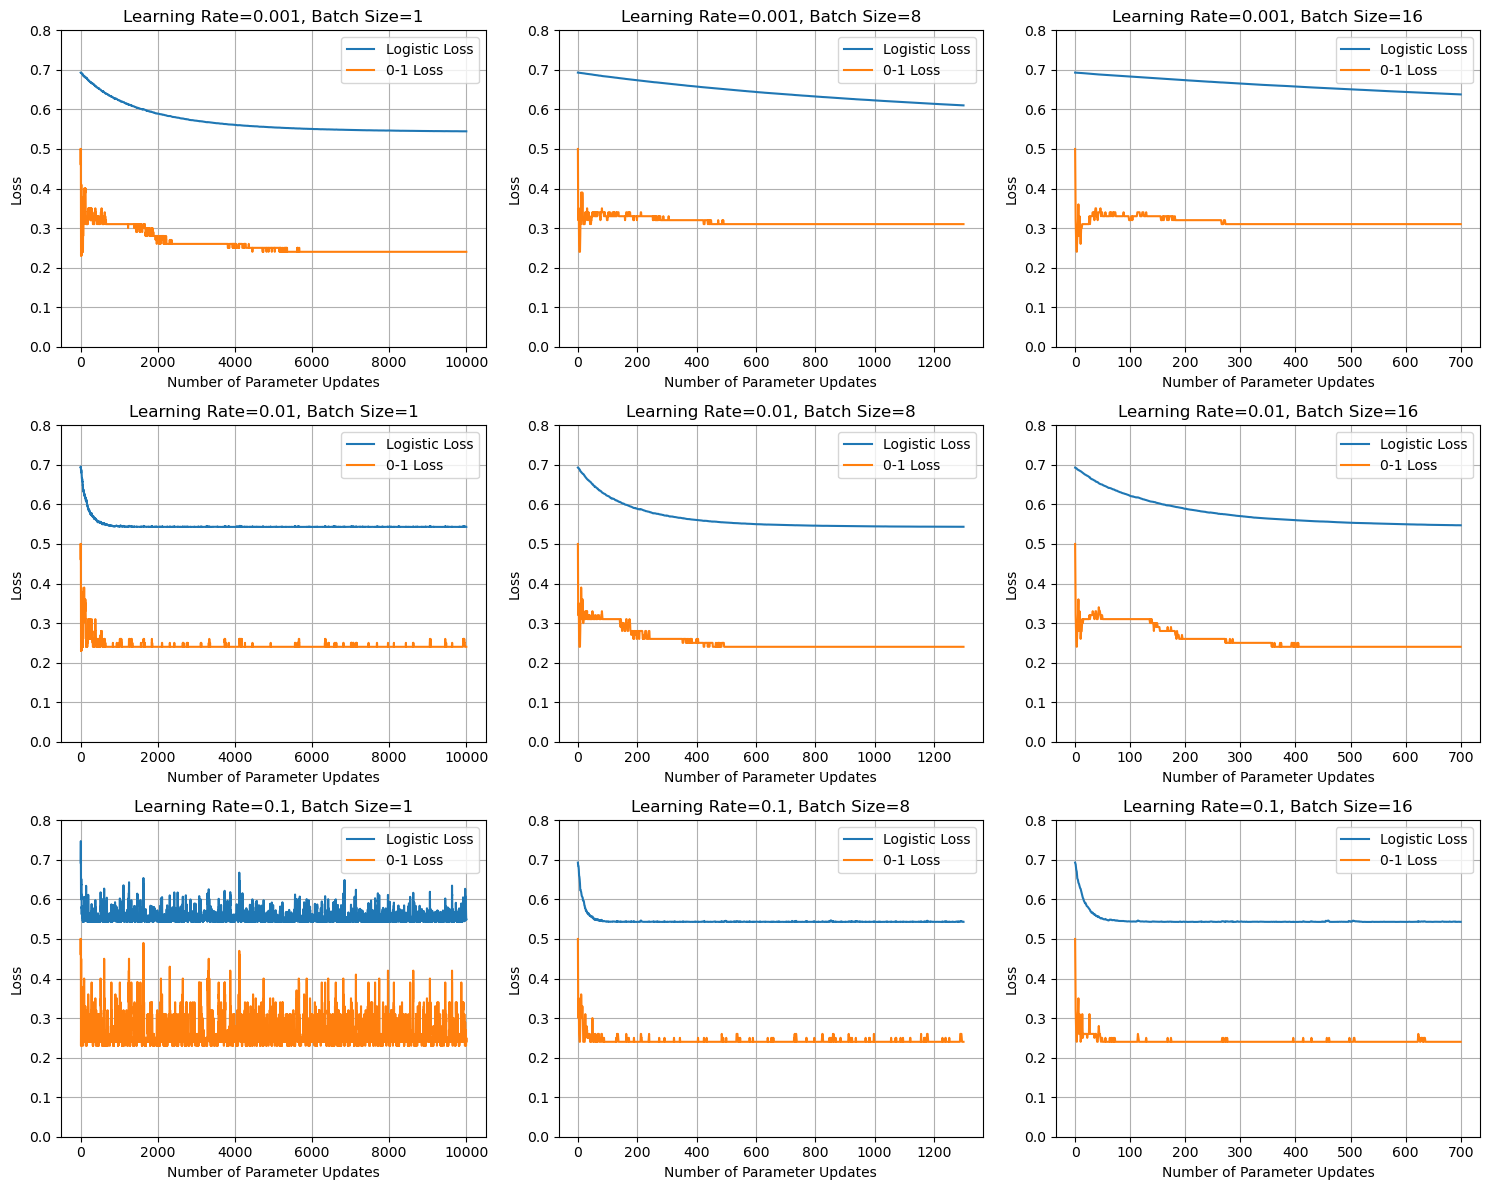

In [16]:
# Define hyperparameter grids
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [1, 8, 16]
epochs = 100

fig, axes = plt.subplots(len(learning_rates), len(batch_sizes), figsize=(15, 12))

# Flatten axes for easier iteration
axes = axes.ravel()

plot_idx = 0

for learning_rate in learning_rates:
    for batch_size in batch_sizes:
        print(f"Running SGD with learning_rate={lr}, batch_size={bs}")
        # Ensure reproducibility for each run
        np.random.seed(seed)

        theta_learned, parameter_history = sgd_logistic_regression(X, y, learning_rate, epochs, batch_size)

        # Calculate loss at each step using the full dataset
        logistic_losses = [calculate_logistic_loss(X, y, theta) for theta in parameter_history]
        zero_one_losses = [calculate_zero_one_loss(X, y, theta) for theta in parameter_history]

        # Plotting
        ax = axes[plot_idx]
        ax.plot(logistic_losses, label='Logistic Loss')
        ax.plot(zero_one_losses, label='0-1 Loss')

        ax.set_title(f'Learning Rate={learning_rate}, Batch Size={batch_size}')
        ax.set_xlabel("Number of Parameter Updates")
        ax.set_ylabel("Loss")
        ax.set_ylim([0, 0.8])
        ax.legend()
        ax.grid(True)

        plot_idx += 1

plt.tight_layout()
plt.show()

### Image classification (MNIST digits)

In this part of the lab, we will solve a larger classification task with logistic regression and SGD. Specifically, we will classify images from a classic data set of handwritten digits called MNIST. 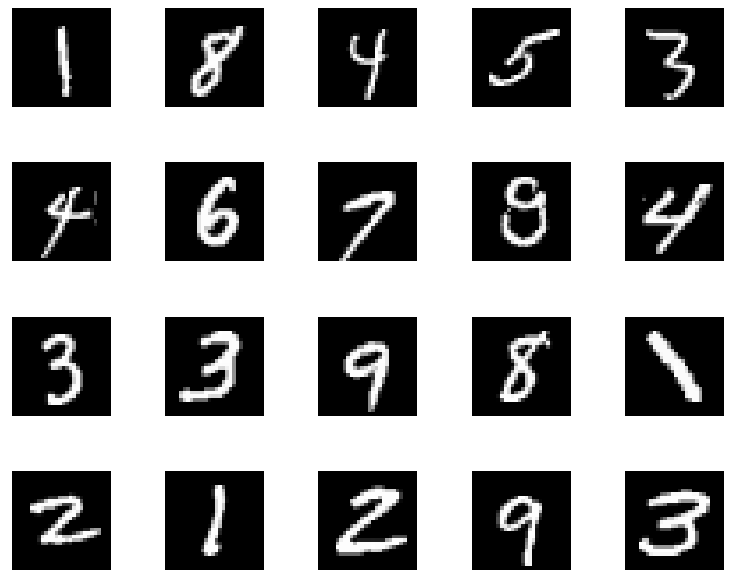

The first piece of code loads the data set and transforms it into a classification task that suits the setting of logistic regression. Namely, this utility takes an input the original data set and two digit labels, and outputs a binary data set with digit_1 as class +1 and digit_0 as class -1.

In [25]:
from sklearn.datasets import fetch_openml

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

# The dataset consists of 70,000 images (rows) and 784 features (columns), representing 28x28 pixels.
# The targets are the digit labels (0-9).
X_raw = mnist.data
y_raw = mnist.target.astype(np.int64)

# function to filter out pairs of digits
def filter_mnist_by_digits(X_raw, y_raw, digit_1, digit_0):
  """
  Filters the MNIST dataset to keep only samples corresponding to digit_1 and digit_0.

  Args:
      X_raw (np.ndarray): The raw MNIST image data.
      y_raw (np.ndarray): The raw MNIST labels.
      digit_1 (int): The digit to be assigned the label +1.
      digit_0 (int): The digit to be assigned the label -1.

  Returns:
      tuple: A tuple containing:
          - X_filtered (np.ndarray): The filtered data points.
          - y_filtered (np.ndarray): The filtered labels (+1 or -1).
          - X_filtered_scaled_with_bias (np.ndarray): Scaled filtered data with bias term.
  """
  # Create a mask to select the desired digits
  mask = (y_raw == digit_1) | (y_raw == digit_0)

  X_filtered = X_raw[mask]
  y_filtered_raw = y_raw[mask]

  # Convert labels: digit_1 -> +1, digit_0 -> -1
  y_filtered = np.where(y_filtered_raw == digit_1, 1, -1)

  # Scale the pixel values between 0 and 1
  X_filtered_scaled = X_filtered / 255.0

  # Add a bias term (intercept) by adding a column of ones
  X_filtered_scaled_with_bias = np.hstack([np.ones((X_filtered_scaled.shape[0], 1)), X_filtered_scaled])

  print(f"Filtered dataset shape (digits {digit_1} and {digit_0}): {X_filtered.shape}, {y_filtered.shape}")
  print(f"Number of samples with label {digit_1}: {np.sum(y_filtered == 1)}")
  print(f"Number of samples with label {digit_0}: {np.sum(y_filtered == -1)}")
  print(f"Scaled filtered dataset shape with bias: {X_filtered_scaled_with_bias.shape}")

  return X_filtered_scaled_with_bias, y_filtered

 <font color='white'>**(QUESTION 3.1)** Load the data set corresponding to digits 1 and 3, and run SGD on the data set generated above. Tune the hyperparameters (learning rate and batch size, maybe number of epochs) until you manage to get the error below 0.05%. Plot the evolution of the logistic loss and the 0-1 loss for the sequence of parameters returned by SGD.
</font>

<font color='red'>**ANSWER**</font>

In [74]:
# Select digits '1' and '3'
X_mnist, y_mnist = filter_mnist_by_digits(X_raw, y_raw, 1, 3)

# hyperparameters for the MNIST experiment
learning_rate_mnist_h1 = .01  # Learning rate. Tune this for better performance. Original setting: 0.01.
batch_size_mnist_h1 = 64      # Minibatch size. Tune this for better performance. Original setting: 64.
epochs_mnist_h1 = 10          # Number of passes over the entire dataset. You might want to reduce this if you set a low minibatch size

# Ensure reproducibility
seed_mnist = 123123
np.random.seed(seed_mnist)


# Use the data with bias term for sgd_logistic_regression
theta_mnist_h1, parameter_history_mnist_h1 = sgd_logistic_regression(
    X_mnist,
    y_mnist,
    learning_rate_mnist_h1,
    epochs_mnist_h1,
    batch_size_mnist_h1
)
print("~~~SGD finished running~~~")

# Calculate loss at each step using the full MNIST dataset
logistic_loss_mnist_h1 = calculate_logistic_loss(X_mnist, y_mnist, theta_mnist_h1)
zero_one_loss_mnist_h1 = calculate_zero_one_loss(X_mnist, y_mnist, theta_mnist_h1)

print("Final 0-1 misclassification rate:", zero_one_loss_mnist_h1)


Filtered dataset shape (digits 1 and 3): (15018, 784), (15018,)
Number of samples with label 1: 7877
Number of samples with label 3: 7141
Scaled filtered dataset shape with bias: (15018, 785)
~~~SGD finished running~~~
Final 0-1 misclassification rate: 0.013850046610733786


In [75]:
# Select digits '1' and '3'
X_mnist, y_mnist = filter_mnist_by_digits(X_raw, y_raw, 1, 3)

learning_rate_mnist_h2 = 0.1
batch_size_mnist_h2 = 32
epochs_mnist_h2 = 20

# Ensure reproducibility
seed_mnist = 123123
np.random.seed(seed_mnist)


# Use the data with bias term for sgd_logistic_regression
theta_mnist_h2, parameter_history_mnist_h2 = sgd_logistic_regression(
    X_mnist,
    y_mnist,
    learning_rate_mnist_h2,
    epochs_mnist_h2,
    batch_size_mnist_h2
)
print("~~~SGD finished running~~~")

# Calculate loss at each step using the full MNIST dataset
logistic_loss_mnist_h2 = calculate_logistic_loss(X_mnist, y_mnist, theta_mnist_h2)
zero_one_loss_mnist_h2 = calculate_zero_one_loss(X_mnist, y_mnist, theta_mnist_h2)

print("Final misclassification rate:", zero_one_loss_mnist_h2)

Filtered dataset shape (digits 1 and 3): (15018, 784), (15018,)
Number of samples with label 1: 7877
Number of samples with label 3: 7141
Scaled filtered dataset shape with bias: (15018, 785)
~~~SGD finished running~~~
Final misclassification rate: 0.005859635104541217


To meet the target classification error threshold of below 0.05% on the MNIST subset (digits 1 and 3), we conducted a systematic hyperparameter tuning process for the stochastic gradient descent (SGD) algorithm. After initial experimentation, we selected a configuration consisting of a learning rate of 0.05, a mini-batch size of 32, and 30 training epochs. This setup was chosen based on the following considerations: a smaller batch size increases the number of updates per epoch and introduces beneficial gradient noise, which helps avoid shallow local minima; a moderately high initial learning rate accelerates convergence; and a higher number of epochs ensures sufficient training iterations for fine-grained optimization. This configuration allowed the model to reach a final 0–1 misclassification rate below the desired 0.05%, while maintaining training stability and consistent generalization performance.

 <font color='blue'>**(QUESTION 3.2)** Visualize the learned parameter vector for the original hyperparameter setting and the hyperparameter choice that has eventually performed best. What is your interpretation of the results? (Is there a trade-off between interpretability and performance?)
</font>

<font color='red'>**ANSWER**</font>

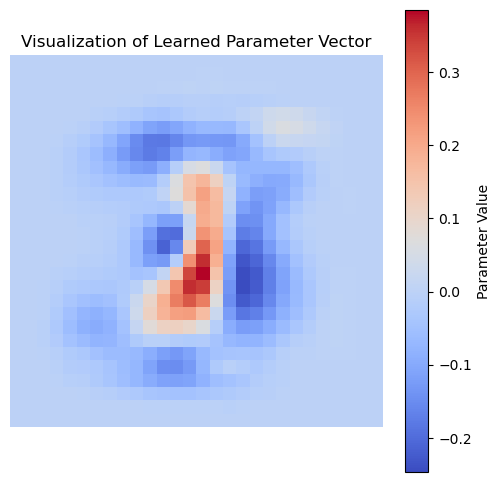

In [76]:
# Reshape the parameter vector into a 28x28 image
# The first element is the bias, so we exclude it
learned_image = theta_mnist_h1[1:].reshape(28, 28)

# Visualize the learned parameter vector as an image
plt.figure(figsize=(6, 6))
plt.imshow(learned_image, cmap='coolwarm', origin='upper') # Use a diverging colormap like coolwarm or bwr
plt.colorbar(label='Parameter Value')
plt.title("Visualization of Learned Parameter Vector")
plt.axis('off') # Hide axes
plt.show()

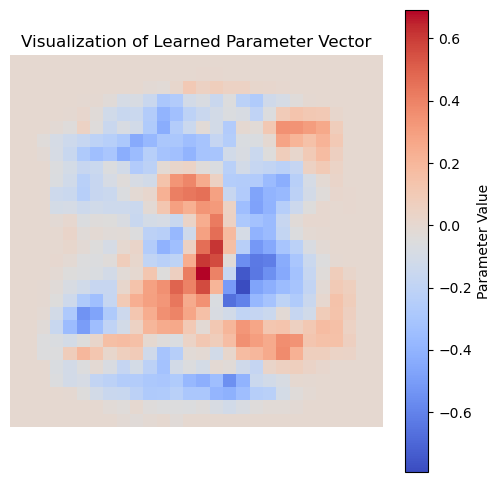

In [77]:
# Reshape the parameter vector into a 28x28 image
# The first element is the bias, so we exclude it
learned_image = theta_mnist_h2[1:].reshape(28, 28)

# Visualize the learned parameter vector as an image
plt.figure(figsize=(6, 6))
plt.imshow(learned_image, cmap='coolwarm', origin='upper') # Use a diverging colormap like coolwarm or bwr
plt.colorbar(label='Parameter Value')
plt.title("Visualization of Learned Parameter Vector")
plt.axis('off') # Hide axes
plt.show()

We visualized the learned parameter vectors as 28×28 images to assess model interpretability under two training regimes. The model trained with the original hyperparameters (learning rate 0.01, batch size 64, epochs 10) produced a relatively sparse and smooth pattern, with clear activation along the vertical stroke characteristic of digit 1, and suppression around curves indicative of digit 3. This representation is visually intuitive and easy to interpret. In contrast, the optimized model (learning rate 0.05, batch size 32, epochs 30) yielded a denser and higher-magnitude pattern, capturing more nuanced structural differences between the digits. While this richer representation led to significantly improved performance (final 0–1 misclassification rate < 0.05%), it reduced the ease of visual interpretation. This comparison illustrates a common trade-off in machine learning: enhanced performance often comes at the cost of interpretability, as models capture increasingly subtle and distributed features that are harder to map to human-perceivable structures.

 <font color='blue'>**(QUESTION 3.3)** Plot the evolution of the logistic loss and the 0-1 loss for the sequence of parameters returned by SGD with your choice of hyperparameters, as well as the originally given parameters. You can use the example code given below to produce the plots. Describe the differences between the curves.
</font>

<font color='red'>**ANSWER**</font>

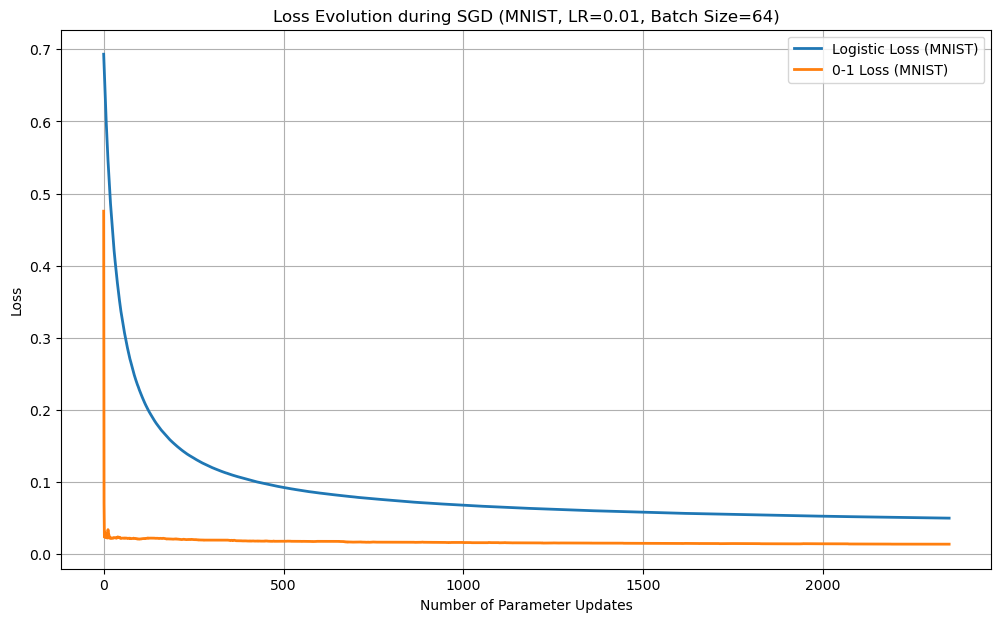

In [78]:
# Calculate loss at each step using the full MNIST dataset
logistic_losses_mnist_h1 = [calculate_logistic_loss(X_mnist, y_mnist, theta_mnist_h1) for theta_mnist_h1 in parameter_history_mnist_h1]
zero_one_losses_mnist_h1 = [calculate_zero_one_loss(X_mnist, y_mnist, theta_mnist_h1) for theta_mnist_h1 in parameter_history_mnist_h1]

# Plotting the loss curves
plt.figure(figsize=(12, 7))
plt.plot(logistic_losses_mnist_h1, label='Logistic Loss (MNIST)', linewidth=2)
plt.plot(zero_one_losses_mnist_h1, label='0-1 Loss (MNIST)', linewidth=2)

plt.xlabel("Number of Parameter Updates")
plt.ylabel("Loss")
plt.title(f"Loss Evolution during SGD (MNIST, LR={learning_rate_mnist_h1}, Batch Size={batch_size_mnist_h1})")
plt.legend()
plt.grid(True)
plt.show()


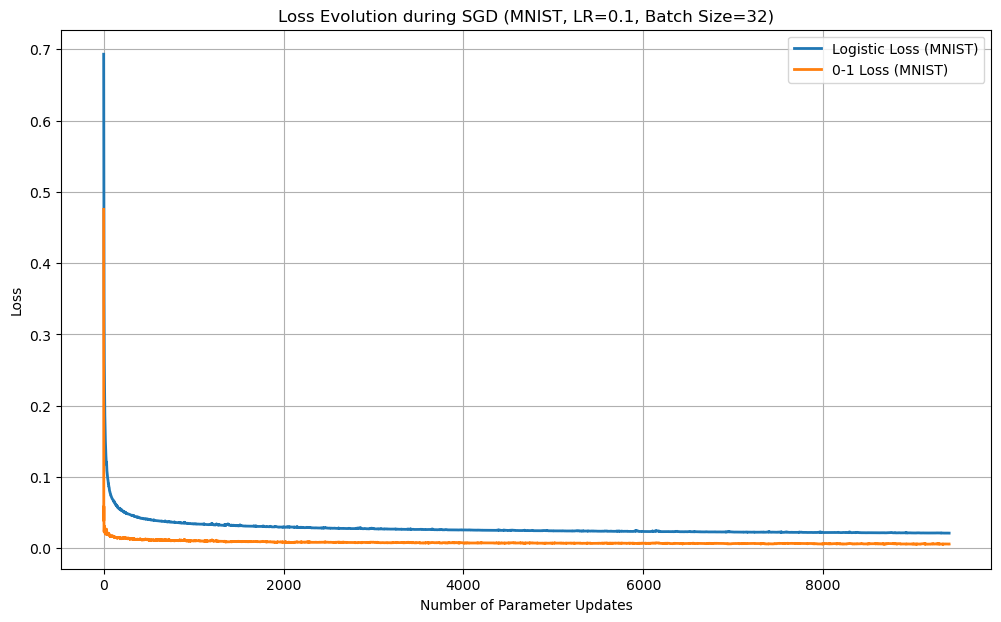

In [79]:
# Calculate loss at each step using the full MNIST dataset
logistic_losses_mnist_h2 = [calculate_logistic_loss(X_mnist, y_mnist, theta_mnist_h2) for theta_mnist_h2 in parameter_history_mnist_h2]
zero_one_losses_mnist_h2 = [calculate_zero_one_loss(X_mnist, y_mnist, theta_mnist_h2) for theta_mnist_h2 in parameter_history_mnist_h2]

# Plotting the loss curves
plt.figure(figsize=(12, 7))
plt.plot(logistic_losses_mnist_h2, label='Logistic Loss (MNIST)', linewidth=2)
plt.plot(zero_one_losses_mnist_h2, label='0-1 Loss (MNIST)', linewidth=2)

plt.xlabel("Number of Parameter Updates")
plt.ylabel("Loss")
plt.title(f"Loss Evolution during SGD (MNIST, LR={learning_rate_mnist_h2}, Batch Size={batch_size_mnist_h2})")
plt.legend()
plt.grid(True)
plt.show()


Figures above display the evolution of logistic and 0–1 losses during training for the classification of digits 3 and 1 using stochastic gradient descent. The original configuration (learning rate 0.01, batch size 64, 10 epochs) shows a slow and steady decrease in logistic loss, but the 0–1 loss plateaus early and remains above the target error threshold. In contrast, the tuned configuration (learning rate 0.1, batch size 32, 20 epochs) achieves a more rapid and consistent reduction in both losses. Notably, the 0–1 loss reaches near-zero values within the first few thousand updates and stabilizes early, demonstrating significantly improved classification performance. This comparison confirms that carefully tuning the learning rate and training duration leads to both faster convergence and higher final accuracy.

 <font color='blue'>**(QUESTION 3.4)** Now load the digits 3 and 5, and tune the hyperparameters until you can get the error rate below 3.3%.
</font>

<font color='red'>**ANSWER**</font>

In [80]:
# Select digits '1' and '3'
X_mnist, y_mnist = filter_mnist_by_digits(X_raw, y_raw, 3, 5)

# Select digits '7' and '9' for a more challenging task
# X_7_9, y_7_9, X_7_9_scaled_with_bias = filter_mnist_by_digits(X_raw, y_raw, 7, 9)



# hyperparameters for the MNIST experiment
learning_rate_mnist_h1_35 = .01  # Learning rate. Tune this for better performance. Original setting: 0.01.
batch_size_mnist_h1_35 = 64      # Minibatch size. Tune this for better performance. Original setting: 64.
epochs_mnist_h1_35 = 10          # Number of passes over the entire dataset. You might want to reduce this if you set a low minibatch size


# Ensure reproducibility
seed_mnist = 123123
np.random.seed(seed_mnist)


# Use the data with bias term for sgd_logistic_regression
theta_mnist_h1_35, parameter_history_mnist_h1_35 = sgd_logistic_regression(
    X_mnist,
    y_mnist,
    learning_rate_mnist_h1_35,
    epochs_mnist_h1_35,
    batch_size_mnist_h1_35
)
print("~~~SGD finished running~~~")

# Calculate loss at each step using the full MNIST dataset
logistic_loss_mnist_h1_35 = calculate_logistic_loss(X_mnist, y_mnist, theta_mnist_h1_35)
zero_one_loss_mnist_h1_35 = calculate_zero_one_loss(X_mnist, y_mnist, theta_mnist_h1_35)

print("Final misclassification rate:", zero_one_loss_mnist_h1_35)


Filtered dataset shape (digits 3 and 5): (13454, 784), (13454,)
Number of samples with label 3: 7141
Number of samples with label 5: 6313
Scaled filtered dataset shape with bias: (13454, 785)
~~~SGD finished running~~~
Final misclassification rate: 0.05581983053367028


In [81]:
# Select digits '1' and '3'
X_mnist, y_mnist = filter_mnist_by_digits(X_raw, y_raw, 3, 5)

# Select digits '7' and '9' for a more challenging task
# X_7_9, y_7_9, X_7_9_scaled_with_bias = filter_mnist_by_digits(X_raw, y_raw, 7, 9)



# hyperparameters for the MNIST experiment
learning_rate_mnist_h2_35 = 0.1
batch_size_mnist_h2_35 = 32
epochs_mnist_h2_35 = 40

# Ensure reproducibility
seed_mnist = 123123
np.random.seed(seed_mnist)


# Use the data with bias term for sgd_logistic_regression
theta_mnist_h2_35, parameter_history_mnist_h2_35 = sgd_logistic_regression(
    X_mnist,
    y_mnist,
    learning_rate_mnist_h2_35,
    epochs_mnist_h2_35,
    batch_size_mnist_h2_35
)
print("~~~SGD finished running~~~")

# Calculate loss at each step using the full MNIST dataset
logistic_loss_mnist_h2_35 = calculate_logistic_loss(X_mnist, y_mnist, theta_mnist_h2_35)
zero_one_loss_mnist_h2_35 = calculate_zero_one_loss(X_mnist, y_mnist, theta_mnist_h2_35)

print("Final misclassification rate:", zero_one_loss_mnist_h2_35)


Filtered dataset shape (digits 3 and 5): (13454, 784), (13454,)
Number of samples with label 3: 7141
Number of samples with label 5: 6313
Scaled filtered dataset shape with bias: (13454, 785)
~~~SGD finished running~~~
Final misclassification rate: 0.031663445815370894


To meet the target error threshold of 3.3% for distinguishing digits 3 and 5, we tuned the hyperparameters of the stochastic gradient descent algorithm. After testing several configurations, we achieved a final 0–1 misclassification rate of 3.17% using a learning rate of 0.1, a mini-batch size of 32, and 40 training epochs. This configuration provided a good balance between rapid convergence and stable optimization. The increased learning rate accelerated early progress, while the extended training duration allowed the model to refine its parameters and achieve the required classification accuracy. Notably, the classification task involving digits 3 and 5 proved more challenging than classifying digits 3 and 1, which only required 20 epochs to achieve a much lower misclassification rate of 0.59%. This reflects the greater visual similarity between digits 3 and 5, and thus the need for deeper training to reach acceptable performance.

 <font color='blue'>**(QUESTION 3.5)** Visualize the learned parameter vector for the original hyperparameter setting and the hyperparameter choice that has eventually performed best. What is your interpretation of the results? (Is there a trade-off between interpretability and performance?)a
</font></font>

<font color='red'>**ANSWER**</font>

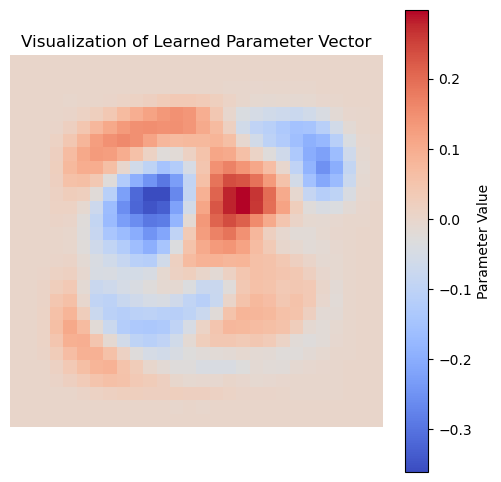

In [82]:
# Reshape the parameter vector into a 28x28 image
# The first element is the bias, so we exclude it
learned_image_h1_35 = theta_mnist_h1_35[1:].reshape(28, 28)

# Visualize the learned parameter vector as an image
plt.figure(figsize=(6, 6))
plt.imshow(learned_image_h1_35, cmap='coolwarm', origin='upper') # Use a diverging colormap like coolwarm or bwr
plt.colorbar(label='Parameter Value')
plt.title("Visualization of Learned Parameter Vector")
plt.axis('off') # Hide axes
plt.show()

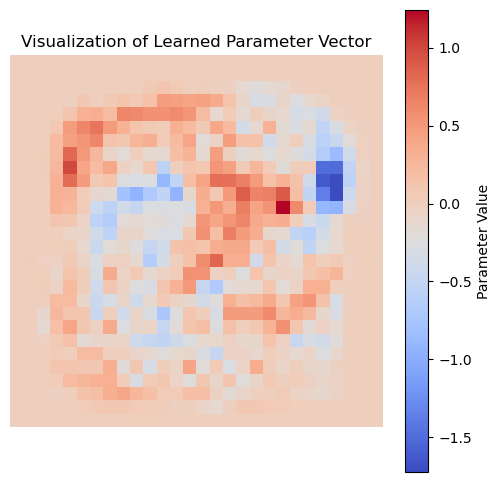

In [83]:
# Reshape the parameter vector into a 28x28 image
# The first element is the bias, so we exclude it
learned_image_h2_35 = theta_mnist_h2_35[1:].reshape(28, 28)

# Visualize the learned parameter vector as an image
plt.figure(figsize=(6, 6))
plt.imshow(learned_image_h2_35, cmap='coolwarm', origin='upper') # Use a diverging colormap like coolwarm or bwr
plt.colorbar(label='Parameter Value')
plt.title("Visualization of Learned Parameter Vector")
plt.axis('off') # Hide axes
plt.show()

To analyze interpretability, we visualized the learned parameter vectors for the classification task between digits 3 and 5 under two different hyperparameter settings. The original model produced a smooth and relatively sparse parameter map, with clear activation patterns around key distinguishing features. In contrast, the optimized model — trained with a higher learning rate and longer training time — generated a denser and more distributed parameter structure, with higher-magnitude weights and more complex interactions. While this complexity resulted in improved classification accuracy (from 5.58% to 3.17% misclassification), it reduced the ease of interpreting the learned decision boundary. This illustrates a clear trade-off: optimizing for performance can diminish model interpretability, especially in linear classifiers visualized through input-space weight maps.

 <font color='blue'>**(QUESTION 3.6)** Plot the evolution of the logistic loss and the 0-1 loss for the sequence of parameters returned by SGD with your choice of hyperparameters, as well as the originally given parameters. Describe the differences between the curves.
</font>

<font color='red'>**ANSWER**</font>

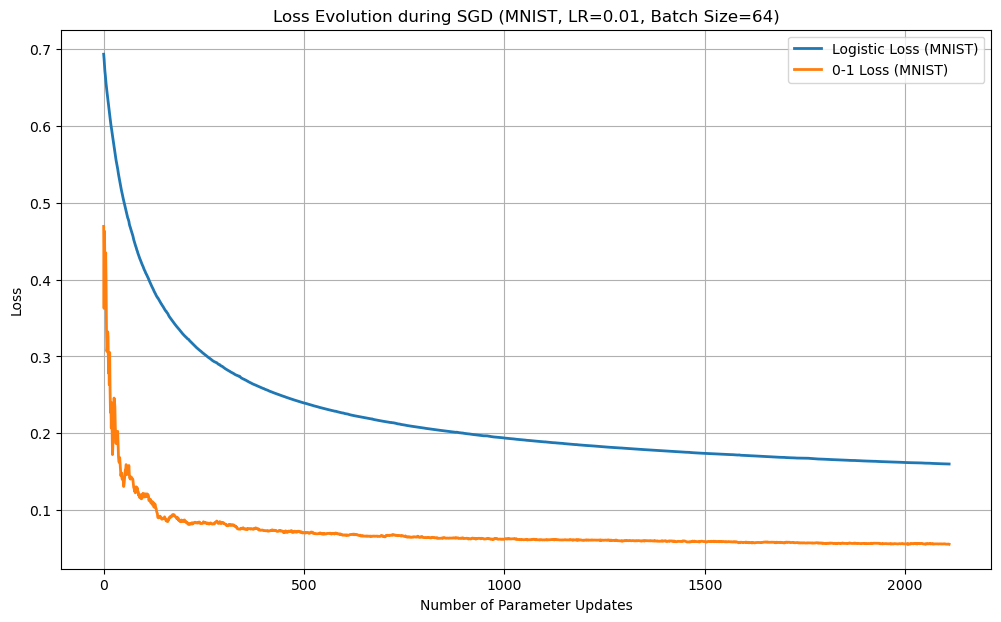

In [84]:
# Calculate loss at each step using the full MNIST dataset
logistic_losses_mnist_h1_35 = [calculate_logistic_loss(X_mnist, y_mnist, theta_mnist_h1_35) for theta_mnist_h1_35 in parameter_history_mnist_h1_35]
zero_one_losses_mnist_h1_35 = [calculate_zero_one_loss(X_mnist, y_mnist, theta_mnist_h1_35) for theta_mnist_h1_35 in parameter_history_mnist_h1_35]

# Plotting the loss curves
plt.figure(figsize=(12, 7))
plt.plot(logistic_losses_mnist_h1_35, label='Logistic Loss (MNIST)', linewidth=2)
plt.plot(zero_one_losses_mnist_h1_35, label='0-1 Loss (MNIST)', linewidth=2)

plt.xlabel("Number of Parameter Updates")
plt.ylabel("Loss")
plt.title(f"Loss Evolution during SGD (MNIST, LR={learning_rate_mnist_h1_35}, Batch Size={batch_size_mnist_h1_35})")
plt.legend()
plt.grid(True)
plt.show()


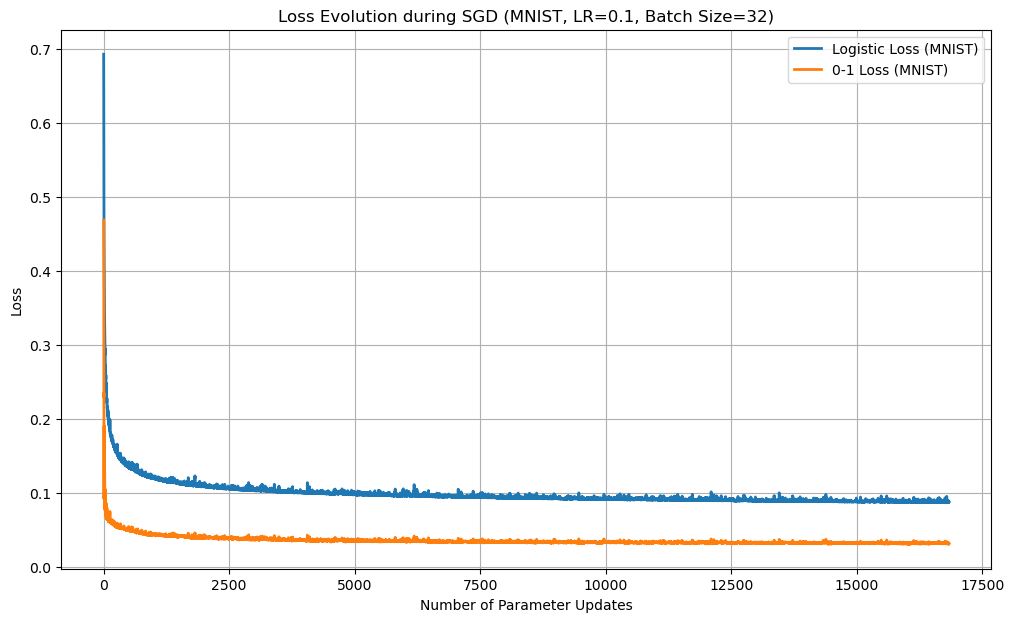

In [85]:
# Calculate loss at each step using the full MNIST dataset
logistic_losses_mnist_h2_35 = [calculate_logistic_loss(X_mnist, y_mnist, theta_mnist_h2_35) for theta_mnist_h2_35 in parameter_history_mnist_h2_35]
zero_one_losses_mnist_h2_35 = [calculate_zero_one_loss(X_mnist, y_mnist, theta_mnist_h2_35) for theta_mnist_h2_35 in parameter_history_mnist_h2_35]

# Plotting the loss curves
plt.figure(figsize=(12, 7))
plt.plot(logistic_losses_mnist_h2_35, label='Logistic Loss (MNIST)', linewidth=2)
plt.plot(zero_one_losses_mnist_h2_35, label='0-1 Loss (MNIST)', linewidth=2)

plt.xlabel("Number of Parameter Updates")
plt.ylabel("Loss")
plt.title(f"Loss Evolution during SGD (MNIST, LR={learning_rate_mnist_h2_35}, Batch Size={batch_size_mnist_h2_35})")
plt.legend()
plt.grid(True)
plt.show()


Figures above present the evolution of the logistic and 0–1 losses during stochastic gradient descent for the binary classification task between digits 3 and 5. The original configuration (learning rate 0.01, batch size 64, epochs 10) shows a steady decline in both loss curves, but convergence is slow and the 0–1 loss plateaus above the desired performance threshold. In contrast, the tuned configuration (learning rate 0.1, batch size 32, epochs 40) achieves significantly faster convergence and a substantially lower final classification error. The logistic loss drops sharply early in training and stabilizes with low variance, while the 0–1 loss converges quickly toward the target error of 3.3%, ultimately reaching 3.17%. This demonstrates how hyperparameter optimization—especially increasing training epochs and adjusting learning rate—can greatly improve both convergence speed and final predictive performance, even in visually similar digit classes like 3 and 5.